# 05 — Evaluation and Error Analysis

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
# When notebooks are launched from notebooks/, move to repository root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "online_retail_II.xlsx"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
MODELS = PROJECT_ROOT / "models"

DATA_PROCESSED.mkdir(exist_ok=True, parents=True)
FIGURES.mkdir(exist_ok=True, parents=True)
MODELS.mkdir(exist_ok=True, parents=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)

model_df = pd.read_csv(
    DATA_PROCESSED / "customer_modeling_data.csv",
    parse_dates=["PredictionDate"]
).sort_values("PredictionDate").reset_index(drop=True)

feature_cols = [
    "RecencyDays", "TransactionCount", "PurchaseDays",
    "TotalSpend", "AverageOrderValue", "TotalQuantity",
    "UniqueProducts", "ActiveMonths", "AvgItemsPerTransaction",
    "PurchaseDaysPerMonth", "Country"
]

unique_dates = np.sort(model_df["PredictionDate"].unique())
train_end = unique_dates[int(len(unique_dates) * 0.70)]
val_end = unique_dates[int(len(unique_dates) * 0.85)]

test = model_df[model_df["PredictionDate"] >= val_end].copy()

X_test = test[feature_cols]
y_test = test["return_30d"]

lr_model = joblib.load(MODELS / "logistic_regression_tuned.joblib")
rf_model = joblib.load(MODELS / "random_forest_tuned.joblib")

lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

lr_pred = (lr_prob >= 0.5).astype(int)
rf_pred = (rf_prob >= 0.5).astype(int)

print("Held-out test observations:", len(test))
print("Test period:", test["PredictionDate"].min(), "to", test["PredictionDate"].max())

Held-out test observations: 11662
Test period: 2011-08-01 00:00:00 to 2011-11-01 00:00:00


## 1. Final test metrics

In [2]:
def evaluate(y_true, pred, prob, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob)
    }

results = pd.DataFrame([
    evaluate(y_test, lr_pred, lr_prob, "Logistic Regression"),
    evaluate(y_test, rf_pred, rf_prob, "Random Forest")
])

display(results)
results.to_csv(DATA_PROCESSED / "final_test_results.csv", index=False)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.698336,0.529798,0.558871,0.543946,0.719333,0.600004
1,Random Forest,0.705882,0.542722,0.548215,0.545455,0.720556,0.604702


## 2. Confusion matrices

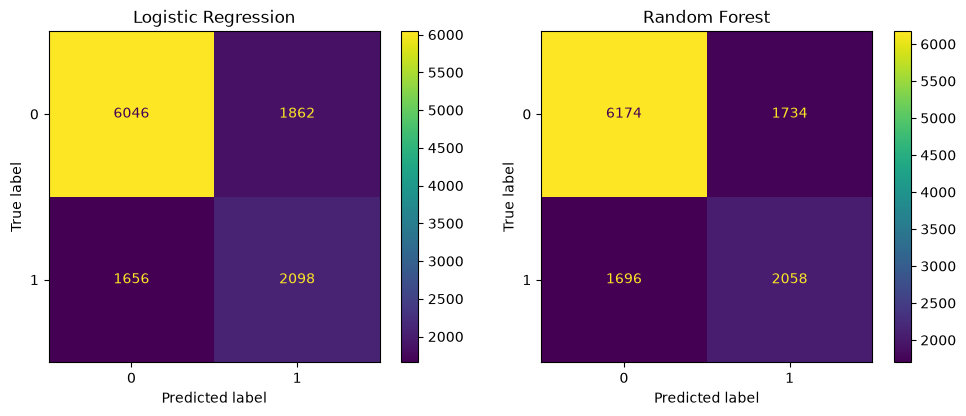

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, ax=axes[0], values_format="d"
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, ax=axes[1], values_format="d"
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrices.png", dpi=160)
plt.show()

## 3. ROC and precision-recall curves

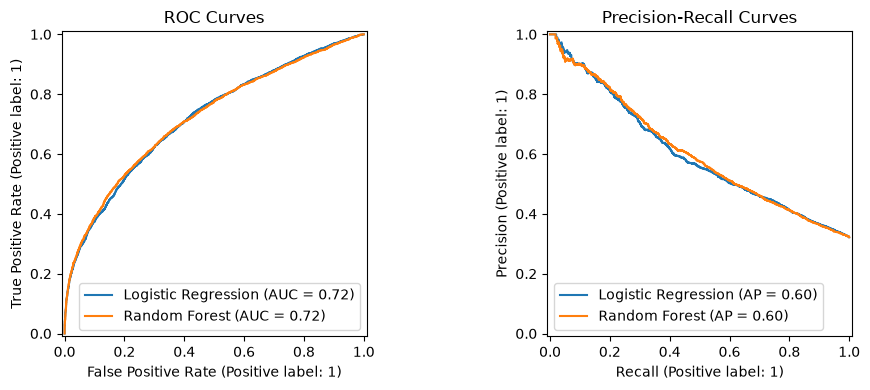

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

RocCurveDisplay.from_predictions(y_test, lr_prob, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, rf_prob, name="Random Forest", ax=axes[0])
axes[0].set_title("ROC Curves")

PrecisionRecallDisplay.from_predictions(y_test, lr_prob, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, rf_prob, name="Random Forest", ax=axes[1])
axes[1].set_title("Precision-Recall Curves")

plt.tight_layout()
plt.savefig(FIGURES / "roc_pr_curves.png", dpi=160)
plt.show()

## 4. Random Forest feature importance

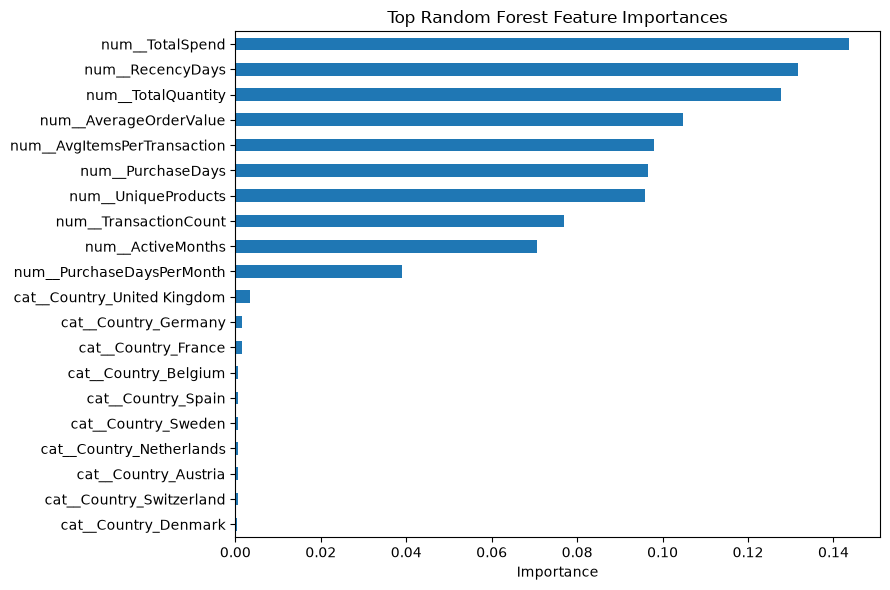

,importance
num__TotalSpend,0.143701
num__RecencyDays,0.131611
num__TotalQuantity,0.127666
num__AverageOrderValue,0.104811
num__AvgItemsPerTransaction,0.097925
num__PurchaseDays,0.096579
num__UniqueProducts,0.095871
num__TransactionCount,0.077005
num__ActiveMonths,0.070572
num__PurchaseDaysPerMonth,0.039037


In [ ]:
prep = rf_model.named_steps["prep"]
rf = rf_model.named_steps["model"]

try:
    names = prep.get_feature_names_out()
    importances = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(20)

    plt.figure(figsize=(9, 6))
    importances.sort_values().plot(kind="barh")
    plt.title("Top Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIGURES / "random_forest_feature_importance.png", dpi=160)
    plt.show()

    display(importances.to_frame("importance"))
except Exception as exc:
    print("Feature-importance plot could not be created:", exc)

## 5. Concrete error analysis

In [6]:
error_df = test[["Customer ID", "PredictionDate", "return_30d"]].copy()
error_df["lr_prob"] = lr_prob
error_df["lr_pred"] = lr_pred
error_df["rf_prob"] = rf_prob
error_df["rf_pred"] = rf_pred

# Use the Random Forest as the example final model for error analysis.
error_df["error_type"] = np.select(
    [
        (error_df["rf_pred"] == 1) & (error_df["return_30d"] == 0),
        (error_df["rf_pred"] == 0) & (error_df["return_30d"] == 1)
    ],
    ["False Positive", "False Negative"],
    default="Correct"
)

fp = error_df[error_df["error_type"] == "False Positive"].sort_values("rf_prob", ascending=False)
fn = error_df[error_df["error_type"] == "False Negative"].sort_values("rf_prob", ascending=True)

print("False positives:", len(fp))
print("False negatives:", len(fn))

display(fp.head(5))
display(fn.head(5))

error_df.to_csv(DATA_PROCESSED / "test_error_analysis.csv", index=False)

False positives: 1734
False negatives: 1696


,Customer ID,PredictionDate,return_30d,lr_prob,lr_pred,rf_prob,rf_pred,error_type
56741,17961,2011-10-01,0,0.984698,1,0.960890,1,False Positive
51085,18198,2011-08-01,0,0.929455,1,0.952769,1,False Positive
51141,18118,2011-08-01,0,0.969094,1,0.950124,1,False Positive
56492,17719,2011-10-01,0,0.949261,1,0.943207,1,False Positive
56091,16525,2011-10-01,0,0.954622,1,0.941823,1,False Positive


,Customer ID,PredictionDate,return_30d,lr_prob,lr_pred,rf_prob,rf_pred,error_type
56191,15299,2011-10-01,1,0.284322,0,0.061270,0,False Negative
53228,16462,2011-09-01,1,0.309801,0,0.100751,0,False Negative
58184,15181,2011-10-01,1,0.299271,0,0.141843,0,False Negative
61739,14452,2011-11-01,1,0.348111,0,0.146531,0,False Negative
52694,14111,2011-08-01,1,0.291525,0,0.149345,0,False Negative
